#### A. Carga y exploración inicial

In [59]:
# Librerias
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
# Cargamos dataset
titanic_df = pd.read_csv('train.csv')

In [4]:
# Mostramos las primeras 5 filas
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Uso de df.info() y df.describe()
print(titanic_df.info())
print("-"*50)
print(titanic_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
--------------------------------------------------
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.

In [53]:
# Identificamos la cantidad de valores nulos
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### B. Limpieza de datos

#### - Plan de limpieza -

**Age (177 nulos):**
- Voy a imputar los valores nulos de Age con la mediana
- Porque: Considerando que entre los pasajeros hay bebés y gente mayor, la mediana podría ser una buena opción

**Cabin (687 nulos):**
- Voy a crear una nueva columna que permita saber si tiene o no cabina
- Porque: Nos permitira saber si el pasajero contaba con cabina o en dado caso era desconocida esa información

**Embarked (2 nulos):**
- Voy a imputar los valores con la moda
- Porque: Son dos pasajeras con el mismo número de ticket, idicando que viajaban juntas, la moda nos permitira no perder las dos filas

In [54]:
# Primero vamos a estandarizar el nombre las columnas para un mejor manejo de las mismas
def limpiar_columnas(df):
    df.columns = (df.columns.str.strip().str.lower().str.replace(' ', '_', regex=False).str.replace('.', '', regex=False))
    return df
# Mandamos nuestro DataFrame
limpiar_columnas(titanic_df)

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [55]:
# Limpieza - Age
titanic_df["age"] = titanic_df["age"].fillna(value=titanic_df["age"].median())

In [56]:
# Limpieza - cabin
# Creamos columna nueva y cambiamos valor nulo para cabin
titanic_df["has_cabin"] = titanic_df["cabin"].notna().astype(int)
# Eliminamos columna
titanic_df = titanic_df.drop(columns=['cabin'])

In [57]:
# Limpieza - embarked
titanic_df["embarked"] = titanic_df["embarked"].fillna(value=titanic_df["embarked"].mode()[0])

In [58]:
# Verificamos que no existan valores nulos
titanic_df.isnull().sum()

passengerid    0
survived       0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
embarked       0
has_cabin      0
dtype: int64

#### C. Análisis exploratorio

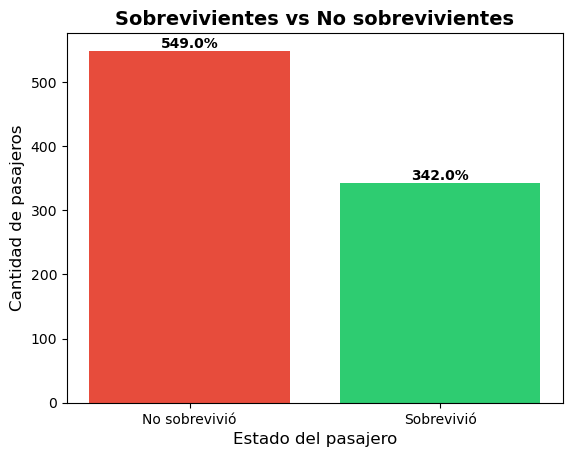

In [113]:
# Calculamos los sobrevivientes
sobrevivientes = titanic_df["survived"].value_counts()
# Generamos etiquetas
etiquetas = ['No sobrevivió', 'Sobrevivió']
# Creamos gráfico
plt.bar(etiquetas, sobrevivientes.values, color=['#e74c3c', '#2ecc71']) 
plt.title('Sobrevivientes vs No sobrevivientes', fontsize=14, fontweight='bold')
plt.xlabel('Estado del pasajero', fontsize=12)
plt.ylabel('Cantidad de pasajeros', fontsize=12)
# Añadimos el número exacto sobre cada barra
for i, v in enumerate(sobrevivientes.values):
    plt.text(i, v + 5, f'{v:.1f}%', ha='center', fontweight='bold')
# Mostramos
plt.show()

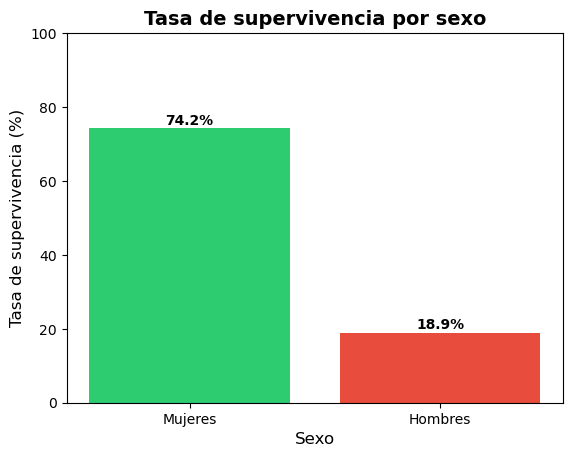

In [ ]:
# Calcular tasa de supervivencia por sexo
tasa_mujeres = titanic_df[titanic_df['sex'] == 'female']['survived'].mean() * 100
tasa_hombres = titanic_df[titanic_df['sex'] == 'male']['survived'].mean() * 100
porcentajes_sex = [tasa_mujeres, tasa_hombres]
etiquetas_sex = ['Mujeres', 'Hombres']
# Generamos gráfico
plt.bar(etiquetas_sex, porcentajes_sex, color=['#2ecc71', '#e74c3c'])
plt.title("Tasa de supervivencia por sexo", fontsize=14, fontweight='bold')
plt.xlabel("Sexo", fontsize=12)
plt.ylabel("Tasa de supervivencia (%)", fontsize=12)
# Mostramos gráfico
for i, v in enumerate(porcentajes_sex):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
# Mostramos gráfico
plt.ylim(0, 100)
plt.show()

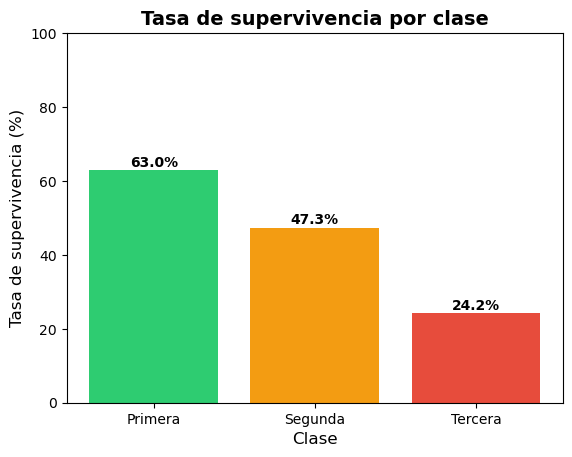

In [ ]:
# Calcular tasa de supervivencia por clase
tasas_clase = []
for clase in [1, 2, 3]:
    tasa = titanic_df[titanic_df['pclass'] == clase]['survived'].mean() * 100
    tasas_clase.append(tasa)
# Generamos gráfico
etiquetas_clase = ['Primera', 'Segunda', 'Tercera']
plt.bar(etiquetas_clase, tasas_clase, color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title("Tasa de supervivencia por clase", fontsize=14, fontweight='bold')
plt.xlabel("Clase", fontsize=12)
plt.ylabel("Tasa de supervivencia (%)", fontsize=12)
for i, v in enumerate(tasas_clase):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
# Mostramos gráfico
plt.ylim(0, 100)
plt.show()

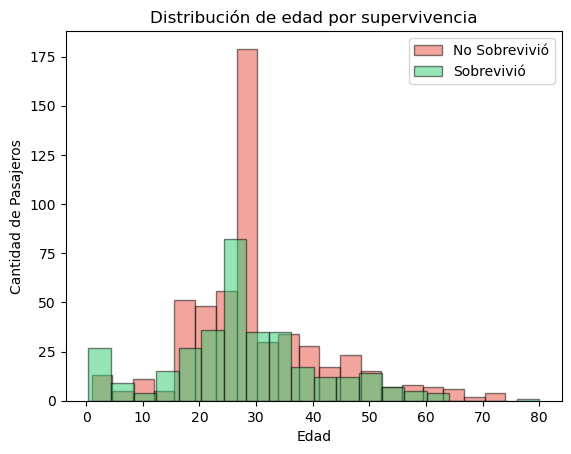

In [103]:
# Obtenemos supervivencia y edad
sobrevivio = titanic_df[titanic_df['survived'] == 1]['age']
no_sobrevivio = titanic_df[titanic_df['survived'] == 0]['age']
# Generamos gráfico
plt.hist(no_sobrevivio, bins=20, alpha=0.5, label='No Sobrevivió', color='#e74c3c', edgecolor='black')
plt.hist(sobrevivio, bins=20, alpha=0.5, label='Sobrevivió', color='#2ecc71', edgecolor='black')
plt.title("Distribución de edad por supervivencia")
plt.xlabel('Edad')
plt.ylabel('Cantidad de Pasajeros')
plt.legend()
# Mostramos gráfico
plt.show()

#### D. Métricas clave

#### E. Observaciones